# Logistic Regression

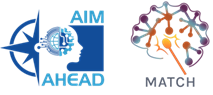

**Objective**

To obtain predictions for patient response to therapy using a logistic regressor trained on our workshop data, and calculate our model's accuracy




**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Predictive modeling using healthcare data. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenter and Code Author: Mignon Dumanjog, M.S., University of Texas at San Antonio<br>

# Import packages & data

You can either load the data from Kaggle (through an API token which can be obtained from your Kaggle settings page), or from local files by uploading *train.csv*, *test.csv*, and *solution.csv* from the [aiMATCH GitHub page.](https://github.com/qutublab/aiMATCH/releases/tag/Predictive-modeling-workshop)<br>Run the cell corresponding to your chosen method.

In [ ]:
import numpy as np
import pandas as pd
import os

*From Kaggle*

In [ ]:
# NEVER SHARE YOUR API TOKEN PUBLICLY.
# Tip: Store your API token as a Secret in Google Colab.
# If running locally, do not commit your .env file or it will expose secrets
# that will allow others to control access to your various AI and authentication provider accounts.
import kagglehub
kagglehub.login()

aimatch_workshop_predicting_health_outcomes_path = kagglehub.competition_download('aimatch-workshop-predicting-health-outcomes')

print('Data source import complete.')

train_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Train.csv'))
test_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Test.csv'))
solution_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Solution.csv'))


Data source import complete.


*From files*

In [ ]:
train_df = pd.read_csv('/path/Train.csv') # change to actual path
test_df = pd.read_csv('/path/Test.csv') # change to actual path
solution_df = test_df = pd.read_csv('/path/Solution.csv') # change to actual path

# Workshop Data Pre-processing


In [ ]:
X_train = train_df.iloc[:,1:-1]
y_train = train_df.iloc[:,-1]
y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)
X_test = test_df

def id_column_type(df):
    numeric_columns = []
    text_columns = []
    for column_name in df.columns:

        if df[column_name].dtype in['int64','float64']:
            numeric_columns.append(df[column_name].name)
        else:
            text_columns.append(df[column_name].name)
    return numeric_columns, text_columns

numeric_features, categorical_features = id_column_type(X_train)

/tmp/ipykernel_4467/3527414801.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = 'median')), # also try 'mean', 'most_frequent', etc.
        ("scaler", StandardScaler())
    ]
)

Xt_num = numeric_transformer.fit_transform(X_train[numeric_features])
Xt_num_df = pd.DataFrame(Xt_num, columns=numeric_features)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Xt_cat = categorical_transformer.fit_transform(X_train[categorical_features])

ohe = categorical_transformer.named_steps["onehot"]

feature_names = ohe.get_feature_names_out(categorical_features)

Xt_cat_df = pd.DataFrame(
    Xt_cat.toarray(),
    columns=feature_names
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
Xt_train_all_cols = pd.DataFrame(preprocessor.fit_transform(X_train))
Xt_train_all_cols.columns = np.append(Xt_num_df.columns.to_numpy(), Xt_cat_df.columns.to_numpy())
display(Xt_train_all_cols)


,Age.Dx,Weight.kg,BMI,HCT,Protein A,Protein B,Protein C,FAB.(Assigned)_M0,FAB.(Assigned)_M1,FAB.(Assigned)_M2,FAB.(Assigned)_M5,FAB.(Assigned)_M6,Age.subgroup_18-40,Age.subgroup_41-60,Age.subgroup_>60,Dysplasia_N,Dysplasia_Y
0,0.748076,0.056415,-0.205500,0.038392,0.706803,-1.041772,0.189591,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.397416,0.027703,-0.219316,-0.920606,-0.853227,0.509397,-0.542929,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.467548,0.282613,0.262492,-0.438667,1.170792,1.274824,1.259898,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.028605,0.266603,-0.219316,0.108724,-0.038599,-0.265585,-0.412872,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.607812,-1.581986,-1.013413,-0.593626,0.095617,-0.037737,1.210461,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,-1.987078,-0.872902,-0.867968,0.327769,-0.582147,-0.645881,-0.207877,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
62,-0.724699,0.743245,-0.293406,0.646619,-1.170258,-0.173780,0.316889,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
63,-0.023377,0.921937,0.145432,1.167974,0.722568,0.232632,1.312287,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
64,-0.233774,-1.471044,-0.400137,2.059362,-0.340242,-0.330125,-0.460139,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
Xt_test_all_cols = pd.DataFrame(preprocessor.fit_transform(X_test))
Xt_test_all_cols.columns = np.append(Xt_num_df.columns.to_numpy(), Xt_cat_df.columns.to_numpy())
display(Xt_test_all_cols)

,Age.Dx,Weight.kg,BMI,HCT,Protein A,Protein B,Protein C,FAB.(Assigned)_M0,FAB.(Assigned)_M1,FAB.(Assigned)_M2,FAB.(Assigned)_M5,FAB.(Assigned)_M6,Age.subgroup_18-40,Age.subgroup_41-60,Age.subgroup_>60,Dysplasia_N,Dysplasia_Y
0,-0.636931,-0.350040,-0.265644,-0.356081,-0.285446,0.328114,0.063995,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.597762,0.628160,-0.187440,0.287678,0.364455,-0.183525,0.334793,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.397810,1.383587,1.688310,-0.918830,0.819932,-0.302935,-0.381211,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-1.228212,-0.348539,-0.386287,0.260752,2.542199,3.302785,1.155402,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.693450,0.567738,1.223275,0.671073,-0.051385,0.411852,-0.601064,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
5,1.136911,-0.150765,-0.046553,-0.386248,0.132471,0.255169,-1.584338,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
6,1.210821,-0.425215,0.226178,0.659582,-0.276463,-0.022402,0.093356,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
7,0.471720,-1.805367,-1.577951,-0.633846,2.631741,-0.251959,2.040564,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
8,-2.558593,1.278735,1.364511,-0.263437,-0.918468,-0.453722,-0.369554,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
9,-0.415201,-1.330947,-1.346492,-0.100943,-1.513672,-0.506735,0.112533,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# Logistic regressor

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
        # Try: ("classifier", LogisticRegression(l1_ratio = 0.1, solver='saga', max_iter=1000))
    ]
)

In [ ]:
lr.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age.Dx', 'Weight.kg', 'BMI',
                                                   'HCT', 'Protein A',
                                                   'Protein B', 'Protein C']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['FAB.(Assigned)',
                                                   'Age.subgroup',
                                                   'Dysplasia'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = lr.predict(X_test)
print(lr.predict_proba(X_test))
print('Class labels:', lr.classes_)

y_proba = lr.predict_proba(X_test)[:, 1]
UPINs = test_df['UPIN']
y_pred_df = pd.DataFrame({'UPIN':UPINs, 'y_pred':y_pred, 'probability':y_proba})

display(y_pred_df)

# ## Uncomment & change file path to generate solution file if uploading to Kaggle
# submission = pd.DataFrame({'UPIN':UPINs, 'Response Simple':y_pred})
# submission.to_csv('/path/submission.csv', index=False) # Save the DataFrame to a CSV file

[[0.04620609 0.95379391]
 [0.03272789 0.96727211]
 [0.65702503 0.34297497]
 [0.12598421 0.87401579]
 [0.25753092 0.74246908]
 [0.84741823 0.15258177]
 [0.50405365 0.49594635]
 [0.70129282 0.29870718]
 [0.00678642 0.99321358]
 [0.08429182 0.91570818]
 [0.10656222 0.89343778]
 [0.65491719 0.34508281]
 [0.50951504 0.49048496]
 [0.09255783 0.90744217]
 [0.47411154 0.52588846]
 [0.74359966 0.25640034]
 [0.37770709 0.62229291]
 [0.48055608 0.51944392]
 [0.24733888 0.75266112]
 [0.78113214 0.21886786]
 [0.02221237 0.97778763]
 [0.35762298 0.64237702]
 [0.38180745 0.61819255]
 [0.62980381 0.37019619]
 [0.03646603 0.96353397]
 [0.40917384 0.59082616]
 [0.6773619  0.3226381 ]
 [0.04226895 0.95773105]
 [0.02229234 0.97770766]
 [0.48348308 0.51651692]
 [0.2916958  0.7083042 ]
 [0.00529942 0.99470058]
 [0.53905049 0.46094951]
 [0.00745138 0.99254862]]
Class labels: [0 1]


,UPIN,y_pred,probability
0,1000001,1,0.953794
1,1000002,1,0.967272
2,1000003,0,0.342975
3,1000004,1,0.874016
4,1000005,1,0.742469
5,1000006,0,0.152582
6,1000007,0,0.495946
7,1000008,0,0.298707
8,1000009,1,0.993214
9,1000010,1,0.915708


# Submit model for scoring

**Accuracy score** <br><br>
$ \text{accuracy} = \frac{\text{number of correctly predicted labels}}{\text{number of samples (in test set)}}$


In [ ]:
accuracy = (y_pred == solution_df['Response Simple']).mean()
print(f"Accuracy: {accuracy}")

Accuracy: 0.7941176470588235
